# DNA Sequence Analysis Project

This project analyzes DNA sequences using bioinformatics techniques:
- Motif detection (ATG)
- GC content analysis
- AT content analysis
- ORF (gene) prediction
- DNA Heatmap Visualization
- DNA → RNA → Protein translation

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
%qtconsole
%matplotlib inline
sys.path.append(os.path.abspath(".."))
from src.dna_analysis import (
    load_fasta,
    gc_content,
    reverse_complement,
    find_motif,
    find_orfs,
    transcribe_dna_to_rna,
    translate_rna,
    naive_with_rc,
)    

In [3]:
p="CCC"
ten_as="A"*10
cp=reverse_complement(p)
t=ten_as+p+ten_as+cp+ten_as
occurrrences=naive_with_rc(p,t)
print(occurrrences)

([0, 1, 2, 3, 4, 5, 6, 7], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])


## Basic DNA Analysis

In this section, we compute fundamental properties of the DNA sequence such as GC content and reverse complement.

In [3]:
print("GC Content:", gc_content(dna))
print("AT Content:",100-gc_content(dna))
rc = reverse_complement(dna)
print("Reverse complement:",rc)

GC Content: 37.84038506849776
AT Content: 62.15961493150224
Reverse complement: ...


## Motif Detection (ATG)

We search for the ATG motif, which represents the start codon and may indicate gene start positions.

In [20]:
positions = find_motif(dna, "ATG")

print("Number of ATG:", len(positions))
print("First positions:", positions[:10])
print("first positions 1 :",positions[:20])

Number of ATG: 723
First positions: [56, 215, 357, 417, 438, 456, 462, 467, 543, 666]
first positions 1 : [56, 215, 357, 417, 438, 456, 462, 467, 543, 666, 725, 759, 786, 841, 906, 912, 951, 1005, 1012, 1086]


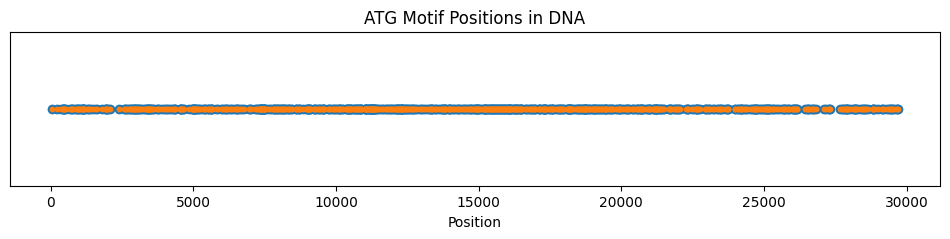

In [5]:
y = [1] * len(positions)

plt.figure(figsize=(12,2))
plt.scatter(positions, y)
plt.scatter(positions, y, s=10)
plt.title("ATG Motif Positions in DNA")
plt.xlabel("Position")
plt.yticks([])
plt.show()

## ORF Detection

Open Reading Frames (ORFs) represent potential protein-coding regions in the DNA sequence.

In [6]:
orfs = find_orfs(dna)

print("Number of ORFs:", len(orfs))
print("First ORFs:", orfs[:5])

Number of ORFs: 722
First ORFs: [(56, 86), (215, 13415), (357, 375), (417, 483), (438, 483)]


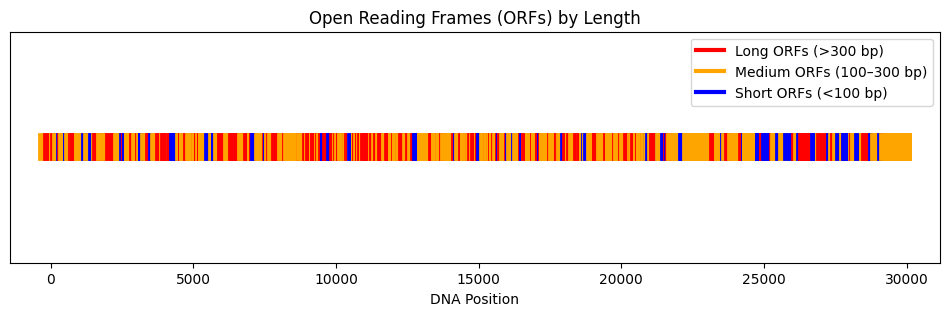

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(12,3))

for start, end in orfs:
    length = end - start
    
    if length > 300:
        color = "red"
    elif length < 100:
        color = "orange"
    else:
        color = "blue"
        
    plt.plot([start, end], [1, 1], linewidth=20, color=color)

# 🔥 Create legend manually
legend_elements = [
    Line2D([0], [0], color='red', lw=3, label='Long ORFs (>300 bp)'),
    Line2D([0], [0], color='orange', lw=3, label='Medium ORFs (100–300 bp)'),
    Line2D([0], [0], color='blue', lw=3, label='Short ORFs (<100 bp)')
]

plt.legend(handles=legend_elements, loc="upper right")

plt.title("Open Reading Frames (ORFs) by Length")
plt.xlabel("DNA Position")
plt.yticks([])

plt.show()

## GC Content Analysis

We analyze how GC content varies across the DNA sequence using a sliding window.

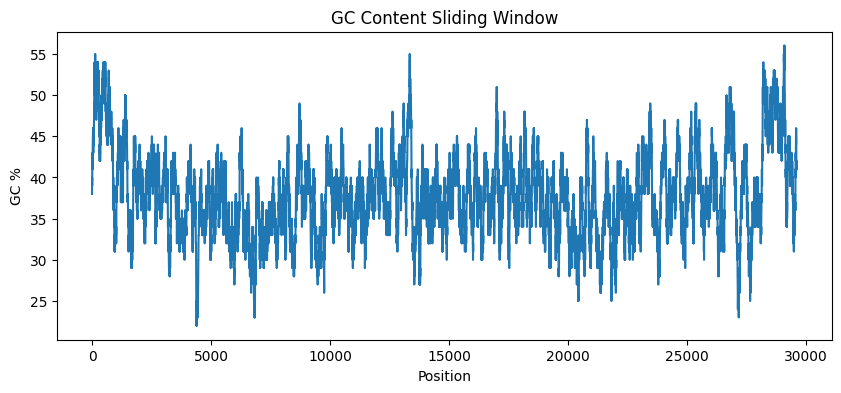

In [8]:
gc_values = []
window_size = 100

for i in range(len(dna) - window_size + 1):
    window = dna[i:i+window_size]
    gc_values.append(gc_content(window))

plt.figure(figsize=(10,4))
plt.plot(gc_values)
plt.title("GC Content Sliding Window")
plt.xlabel("Position")
plt.ylabel("GC %")
plt.show()

## AT Content Analysis

We analyze how AT content varies across the DNA sequence using a sliding window.

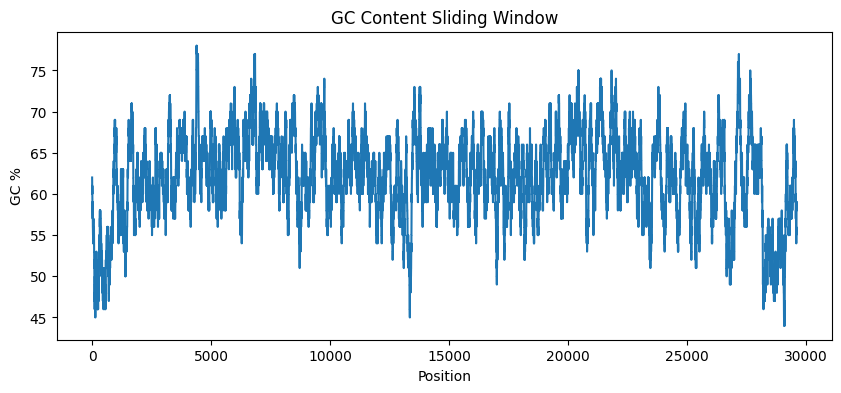

In [9]:
at_values = []
window_size = 100
for i in range(len(dna) - window_size + 1):
    window = dna[i:i+window_size]
    at_values.append(100-gc_content(window))

plt.figure(figsize=(10,4))
plt.plot(at_values)
plt.title("GC Content Sliding Window")
plt.xlabel("Position")
plt.ylabel("GC %")
plt.show()


## DNA Heatmap Visualization

This visualization represents the DNA sequence as a color-coded matrix.

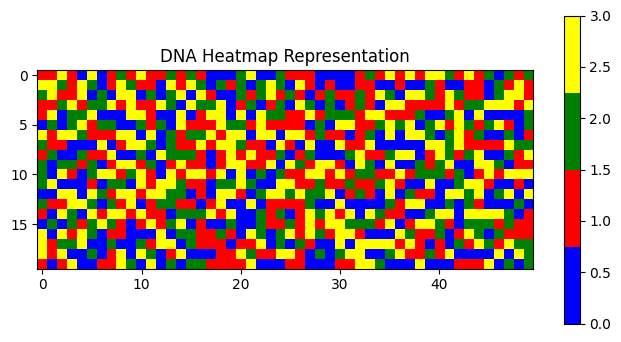

In [10]:
from matplotlib.colors import ListedColormap
# Convert DNA to numbers
mapping = {"A":0, "T":1, "C":2, "G":3}
numeric_seq = [mapping[b] for b in dna if b in mapping]
# reshape into matrix
matrix = np.array(numeric_seq[:1000]).reshape(20,50)
cmap = ListedColormap(["blue", "red", "green", "yellow"])
plt.figure(figsize=(8,4))
plt.imshow(matrix, cmap=cmap)
plt.title("DNA Heatmap Representation")
plt.colorbar()
plt.show()

## DNA to mRNA to Protein Translation

We convert DNA into mRNA and then translate it into a protein sequence.

In [11]:
rna = transcribe_dna_to_rna(dna)
print("mRNA :", rna[:])

protein = translate_rna(rna)
print("Protein :", protein[:])

mRNA : ...
Protein : L(stop)ICSLNEL(stop)NLCGCHSAACLVHSRSIINN(stop)LLSLTGHE(stop)LVYLLQAAYGFVRVAADHQHI(stop)VLSGCDRKVRWRALSLVSTRKHTSNSVCLFYRFATCSYVALETPWRRSYQRHVNILKMALVA(stop)(stop)KLKKAFCLNLNSPMCSSNVRMLELHLMVMLWLSW(stop)QNSKAFSTVVVVRHLVSLSLMWAKYQWLTARFFFVRTVIKELVAIGTAPI(stop)T(stop)ATSLALILMKIFKKTGTLNIAVVLPVNSCVSLTEGHTLAMSITTSVALMATLLSALKTF(stop)HVLVKLHALCPNNWTLLTLRGVYTAAVNMSMKLLGTRNVLKRAMNCRHLLKLNWQRNLTPSMGNVQILYFP(stop)IP(stop)SRLFNQGLKRKSLMALWVEFDLSIQLRHQMNATKCAFQLS(stop)SVIIVVKLHGRRAILLKPLANFVALRI(stop)LKKVPLLVVTYPKMLLLKFIVQHVTIQK(stop)DLSIVLPNTIMNLA(stop)KPFFVRVVALLPLEAVCSLMLVAITSVPIGFHVLALT(stop)VVTIQVLLEKVPKVLMTTFLKYSKKRKSTSILLVTLNLMKRSPLFWHLFLLPQVLLWKL(stop)KVWIIKHSNKLLNPVVILKLQKEKLKKVPGILVNRNQY(stop)VLFMHLHQRLLVLYDQFSPALLKLLKILCVFYRRPL(stop)QY(stop)MEFHSIH(stop)DSLML(stop)CSHLIWLLTI(stop)L(stop)WPTLQVVLFS(stop)LRSG(stop)LTSLALFMKNSNPSLIGLKRSLRKV(stop)SFLETVGKLLNLSQPVLVKLSVDKLSPVQRKLRRVFRHSLSL(stop)INFWLCVLTLSLLVELNLKP(stop)I(stop)VKHLSRTQRDCTESVLNPEKKLAYSCL(stop)KPQKKLSS(sto